<a href="https://colab.research.google.com/github/Nandhini-s21/Performance-Analysis-of-Random-Forest-and-AdaBoost---ML-mini-prjct/blob/main/ML_PRJCT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

data = pd.read_csv("/content/heart_disease.csv")
data.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [3]:
data = pd.read_csv("/content/heart_disease.csv")

print("Dataset Loaded Successfully")
data.head()

Dataset Loaded Successfully


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

In [5]:
# Convert target column (Yes/No → 1/0)
data["Heart Disease Status"] = data["Heart Disease Status"].map({"Yes":1, "No":0})

# Convert categorical columns into numbers
data = pd.get_dummies(data, drop_first=True)

data.head()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,...,Diabetes_Yes,High Blood Pressure_Yes,Low HDL Cholesterol_Yes,High LDL Cholesterol_Yes,Alcohol Consumption_Low,Alcohol Consumption_Medium,Stress Level_Low,Stress Level_Medium,Sugar Consumption_Low,Sugar Consumption_Medium
0,56.0,153.0,155.0,24.991591,7.633228,342.0,NaN,12.969246,12.387250,0,...,False,True,True,False,False,False,False,True,False,True
1,69.0,146.0,286.0,25.221799,8.744034,133.0,157.0,9.355389,19.298875,0,...,True,False,True,False,False,True,False,False,False,True
2,46.0,126.0,216.0,29.855447,4.440440,393.0,92.0,12.709873,11.230926,0,...,False,False,True,True,True,False,True,False,True,False
3,32.0,122.0,293.0,24.130477,5.249405,293.0,94.0,12.509046,5.961958,0,...,False,True,False,True,True,False,False,False,False,False
4,60.0,166.0,242.0,20.486289,7.030971,263.0,154.0,10.381259,8.153887,0,...,True,True,False,False,True,False,False,False,False,False


In [10]:
# Check missing values
print("Missing values:\n", data.isnull().sum())

# Fill missing values with mean
data = data.fillna(data.mean())

print("\nMissing values after fixing:\n", data.isnull().sum())

Missing values:
 Age                           29
Blood Pressure                19
Cholesterol Level             30
BMI                           22
Sleep Hours                   25
Triglyceride Level            26
Fasting Blood Sugar           22
CRP Level                     26
Homocysteine Level            20
Heart Disease Status           0
Gender_Male                    0
Exercise Habits_Low            0
Exercise Habits_Medium         0
Smoking_Yes                    0
Family Heart Disease_Yes       0
Diabetes_Yes                   0
High Blood Pressure_Yes        0
Low HDL Cholesterol_Yes        0
High LDL Cholesterol_Yes       0
Alcohol Consumption_Low        0
Alcohol Consumption_Medium     0
Stress Level_Low               0
Stress Level_Medium            0
Sugar Consumption_Low          0
Sugar Consumption_Medium       0
dtype: int64

Missing values after fixing:
 Age                           0
Blood Pressure                0
Cholesterol Level             0
BMI               

In [11]:
X = data.drop("Heart Disease Status", axis=1)
y = data["Heart Disease Status"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 24)
Target shape: (10000,)


In [33]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()

X, y = smote.fit_resample(X, y)

print("After balancing:", y.value_counts())

After balancing: Heart Disease Status
0    8000
1    8000
Name: count, dtype: int64


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (12800, 24)
Testing data: (3200, 24)


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data scaled successfully")

Data scaled successfully


In [36]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced_subsample',
    random_state=42
)

In [37]:
ab = AdaBoostClassifier(
    n_estimators=300,
    learning_rate=0.5,
    random_state=42
)

In [38]:
rf.fit(X_train, y_train)
ab.fit(X_train, y_train)

print("Models trained successfully")

Models trained successfully


In [39]:
rf_pred = rf.predict(X_test)
ab_pred = ab.predict(X_test)

In [40]:
rf_acc = accuracy_score(y_test, rf_pred)
ab_acc = accuracy_score(y_test, ab_pred)

rf_f1 = f1_score(y_test, rf_pred)
ab_f1 = f1_score(y_test, ab_pred)

print("Random Forest Accuracy:", rf_acc)
print("AdaBoost Accuracy:", ab_acc)

print("\nRandom Forest Report:\n", classification_report(y_test, rf_pred, zero_division=1))
print("\nAdaBoost Report:\n", classification_report(y_test, ab_pred, zero_division=1))

Random Forest Accuracy: 0.799375
AdaBoost Accuracy: 0.7515625

Random Forest Report:
               precision    recall  f1-score   support

           0       0.76      0.87      0.81      1600
           1       0.85      0.73      0.78      1600

    accuracy                           0.80      3200
   macro avg       0.81      0.80      0.80      3200
weighted avg       0.81      0.80      0.80      3200


AdaBoost Report:
               precision    recall  f1-score   support

           0       0.76      0.74      0.75      1600
           1       0.75      0.76      0.75      1600

    accuracy                           0.75      3200
   macro avg       0.75      0.75      0.75      3200
weighted avg       0.75      0.75      0.75      3200



In [41]:
import pandas as pd

# Create comparison table
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],

    "Random Forest": [
        accuracy_score(y_test, rf_pred),
        classification_report(y_test, rf_pred, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test, rf_pred, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test, rf_pred, output_dict=True)['weighted avg']['f1-score']
    ],

    "AdaBoost": [
        accuracy_score(y_test, ab_pred),
        classification_report(y_test, ab_pred, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test, ab_pred, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test, ab_pred, output_dict=True)['weighted avg']['f1-score']
    ]
})

print("\n===== MODEL COMPARISON =====")
print(comparison)


===== MODEL COMPARISON =====
      Metric  Random Forest  AdaBoost
0   Accuracy       0.799375  0.751563
1  Precision       0.805144  0.751624
2     Recall       0.799375  0.751563
3   F1 Score       0.798422  0.751547


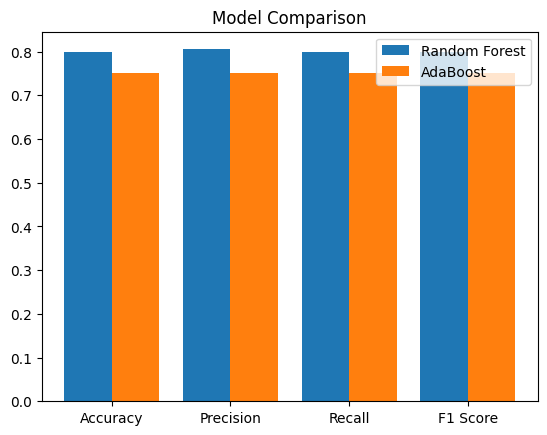

In [42]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

rf_values = comparison["Random Forest"]
ab_values = comparison["AdaBoost"]

x = range(len(metrics))

plt.figure()
plt.bar(x, rf_values, width=0.4, label="Random Forest")
plt.bar([i + 0.4 for i in x], ab_values, width=0.4, label="AdaBoost")

plt.xticks([i + 0.2 for i in x], metrics)
plt.title("Model Comparison")
plt.legend()
plt.show()

In [43]:
import time

# Measure training time
start = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - start

start = time.time()
ab.fit(X_train, y_train)
ab_time = time.time() - start

# Predictions
rf_pred = rf.predict(X_test)
ab_pred = ab.predict(X_test)

# Metrics
from sklearn.metrics import accuracy_score, f1_score

rf_acc = accuracy_score(y_test, rf_pred)
ab_acc = accuracy_score(y_test, ab_pred)

rf_f1 = f1_score(y_test, rf_pred)
ab_f1 = f1_score(y_test, ab_pred)

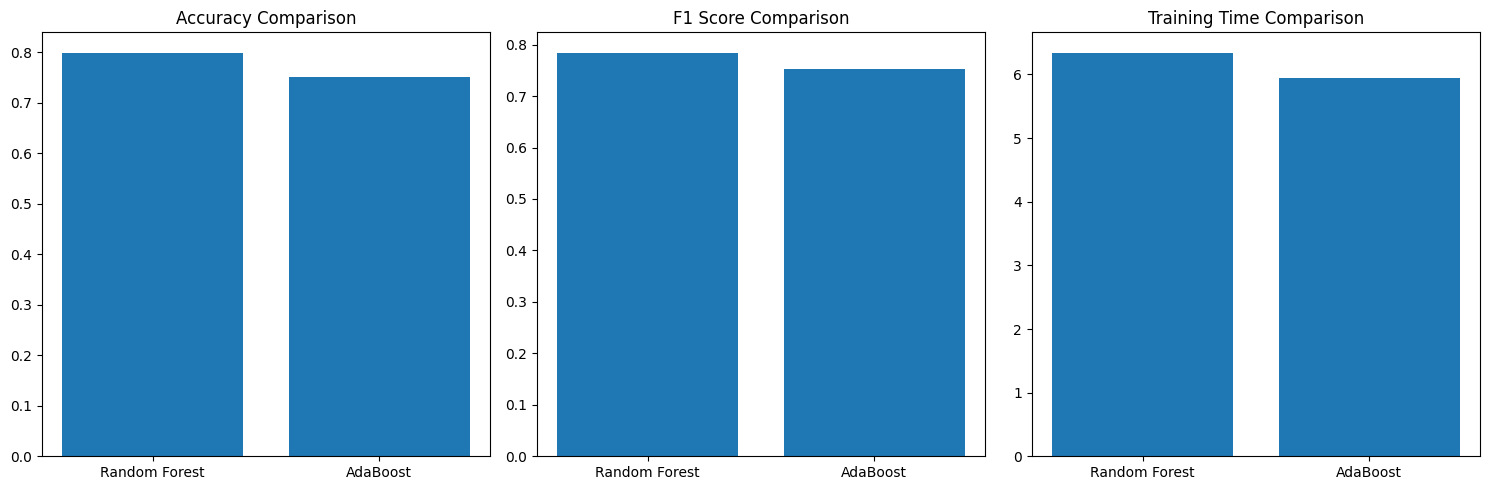

In [44]:
import matplotlib.pyplot as plt

models = ["Random Forest", "AdaBoost"]

# Accuracy
accuracy = [rf_acc, ab_acc]

# F1 Score
f1_scores = [rf_f1, ab_f1]

# Training Time
training_time = [rf_time, ab_time]

plt.figure(figsize=(15,5))

# Accuracy Plot
plt.subplot(1,3,1)
plt.bar(models, accuracy)
plt.title("Accuracy Comparison")

# F1 Score Plot
plt.subplot(1,3,2)
plt.bar(models, f1_scores)
plt.title("F1 Score Comparison")

# Training Time Plot
plt.subplot(1,3,3)
plt.bar(models, training_time)
plt.title("Training Time Comparison")

plt.tight_layout()
plt.show()


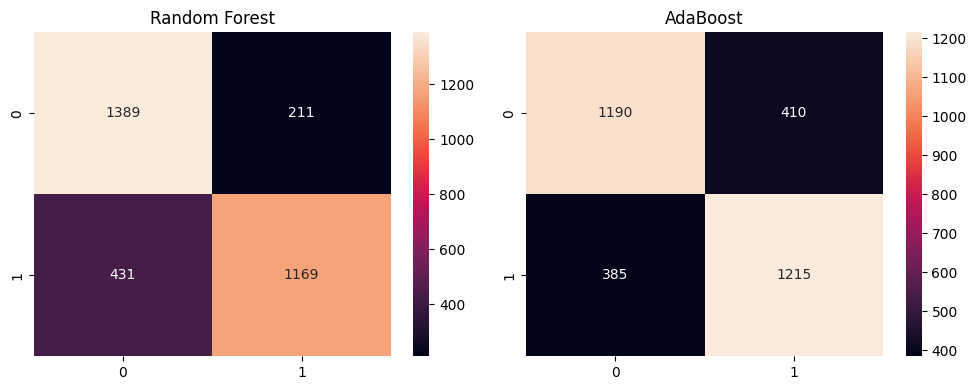

In [46]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(10,4))

# Random Forest
plt.subplot(1,2,1)
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Random Forest")

# AdaBoost
plt.subplot(1,2,2)
cm_ab = confusion_matrix(y_test, ab_pred)
sns.heatmap(cm_ab, annot=True, fmt='d')
plt.title("AdaBoost")

plt.tight_layout()
plt.show()

In [50]:
import pandas as pd

summary = pd.DataFrame({
    "Model": ["Random Forest", "AdaBoost"],
    "Accuracy": [rf_acc, ab_acc],
    "F1 Score": [rf_f1, ab_f1],
    "Training Time (s)": [rf_time, ab_time]
})

print("\n====================Summary of Results=====================\n")
print(summary)


====================Summary of Results=====================

           Model  Accuracy  F1 Score  Training Time (s)
0  Random Forest  0.799375  0.784564           6.344553
1       AdaBoost  0.751563  0.753488           5.951165


Dataset Loaded Successfully
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float

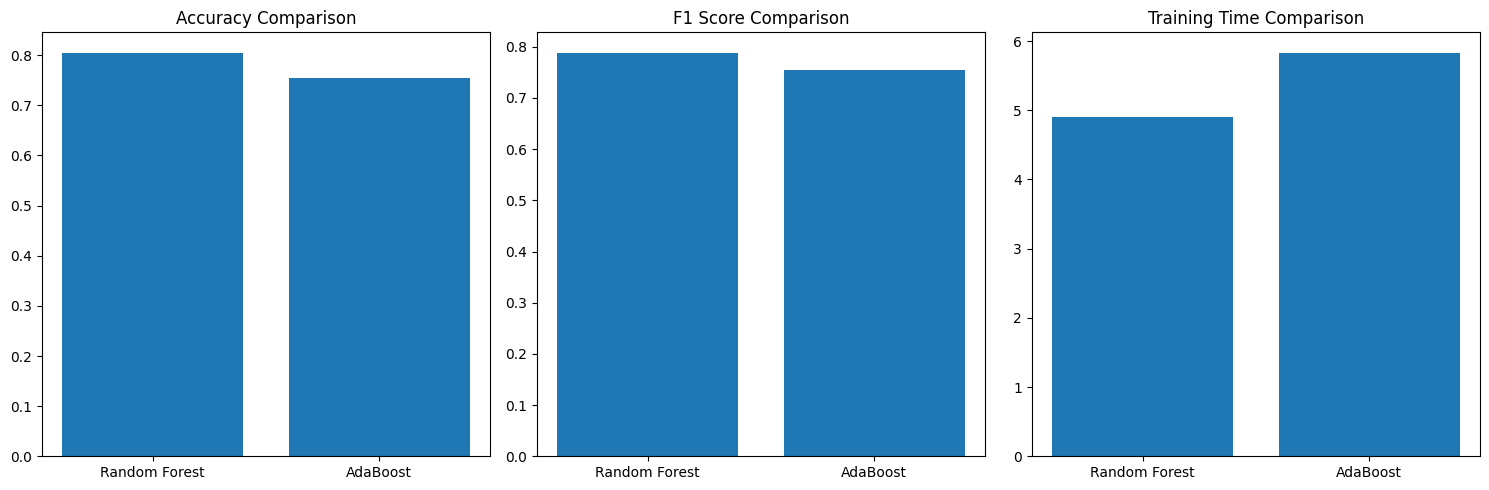

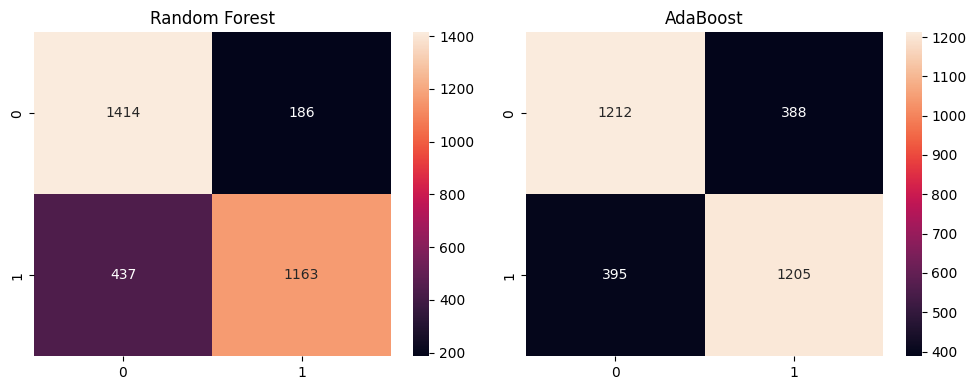


====================Summary of Results=====================

           Model  Accuracy  F1 Score  Training Time (s)
0  Random Forest  0.805312  0.788742           4.907237
1       AdaBoost  0.755313  0.754776           5.834525


In [51]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

data = pd.read_csv("/content/heart_disease.csv")
print("Dataset Loaded Successfully")
data.head()

data.info()

data["Heart Disease Status"] = data["Heart Disease Status"].map({"Yes":1, "No":0})
data = pd.get_dummies(data, drop_first=True)
data.head()

print("Missing values:\n", data.isnull().sum())
data = data.fillna(data.mean())
print("\nMissing values after fixing:\n", data.isnull().sum())

X = data.drop("Heart Disease Status", axis=1)
y = data["Heart Disease Status"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

from imblearn.over_sampling import SMOTE
smote = SMOTE()
X, y = smote.fit_resample(X, y)
print("After balancing:", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=200,max_depth=10,class_weight='balanced_subsample',random_state=42)
ab = AdaBoostClassifier(n_estimators=300,learning_rate=0.5,random_state=42)

rf.fit(X_train, y_train)
ab.fit(X_train, y_train)
print("Models trained successfully")

rf_pred = rf.predict(X_test)
ab_pred = ab.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
ab_acc = accuracy_score(y_test, ab_pred)

rf_f1 = f1_score(y_test, rf_pred)
ab_f1 = f1_score(y_test, ab_pred)

print("Random Forest Accuracy:", rf_acc)
print("AdaBoost Accuracy:", ab_acc)

print("\nRandom Forest Report:\n", classification_report(y_test, rf_pred, zero_division=1))
print("\nAdaBoost Report:\n", classification_report(y_test, ab_pred, zero_division=1))

import pandas as pd

# Create comparison table
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],

    "Random Forest": [
        accuracy_score(y_test, rf_pred),
        classification_report(y_test, rf_pred, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test, rf_pred, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test, rf_pred, output_dict=True)['weighted avg']['f1-score']
    ],

    "AdaBoost": [
        accuracy_score(y_test, ab_pred),
        classification_report(y_test, ab_pred, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test, ab_pred, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test, ab_pred, output_dict=True)['weighted avg']['f1-score']
    ]
})

print("\n===== MODEL COMPARISON =====")
print(comparison)

import time

# Measure training time
start = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - start

start = time.time()
ab.fit(X_train, y_train)
ab_time = time.time() - start

# Predictions
rf_pred = rf.predict(X_test)
ab_pred = ab.predict(X_test)

# Metrics
from sklearn.metrics import accuracy_score, f1_score

rf_acc = accuracy_score(y_test, rf_pred)
ab_acc = accuracy_score(y_test, ab_pred)

rf_f1 = f1_score(y_test, rf_pred)
ab_f1 = f1_score(y_test, ab_pred)

import matplotlib.pyplot as plt

models = ["Random Forest", "AdaBoost"]

# Accuracy
accuracy = [rf_acc, ab_acc]

# F1 Score
f1_scores = [rf_f1, ab_f1]

# Training Time
training_time = [rf_time, ab_time]

plt.figure(figsize=(15,5))

# Accuracy Plot
plt.subplot(1,3,1)
plt.bar(models, accuracy)
plt.title("Accuracy Comparison")

# F1 Score Plot
plt.subplot(1,3,2)
plt.bar(models, f1_scores)
plt.title("F1 Score Comparison")

# Training Time Plot
plt.subplot(1,3,3)
plt.bar(models, training_time)
plt.title("Training Time Comparison")

plt.tight_layout()
plt.show()

import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(10,4))

# Random Forest
plt.subplot(1,2,1)
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Random Forest")

# AdaBoost
plt.subplot(1,2,2)
cm_ab = confusion_matrix(y_test, ab_pred)
sns.heatmap(cm_ab, annot=True, fmt='d')
plt.title("AdaBoost")

plt.tight_layout()
plt.show()

import pandas as pd

summary = pd.DataFrame({
    "Model": ["Random Forest", "AdaBoost"],
    "Accuracy": [rf_acc, ab_acc],
    "F1 Score": [rf_f1, ab_f1],
    "Training Time (s)": [rf_time, ab_time]
})

print("\n====================Summary of Results=====================\n")
print(summary)

Dataset Loaded Successfully
    Age  Gender  Blood Pressure  Cholesterol Level Exercise Habits Smoking  \
0  56.0    Male           153.0              155.0            High     Yes   
1  69.0  Female           146.0              286.0            High      No   
2  46.0    Male           126.0              216.0             Low      No   
3  32.0  Female           122.0              293.0            High     Yes   
4  60.0    Male           166.0              242.0             Low     Yes   

  Family Heart Disease Diabetes        BMI High Blood Pressure  ...  \
0                  Yes       No  24.991591                 Yes  ...   
1                  Yes      Yes  25.221799                  No  ...   
2                   No       No  29.855447                  No  ...   
3                  Yes       No  24.130477                 Yes  ...   
4                  Yes      Yes  20.486289                 Yes  ...   

  High LDL Cholesterol Alcohol Consumption Stress Level Sleep Hours  \
0    

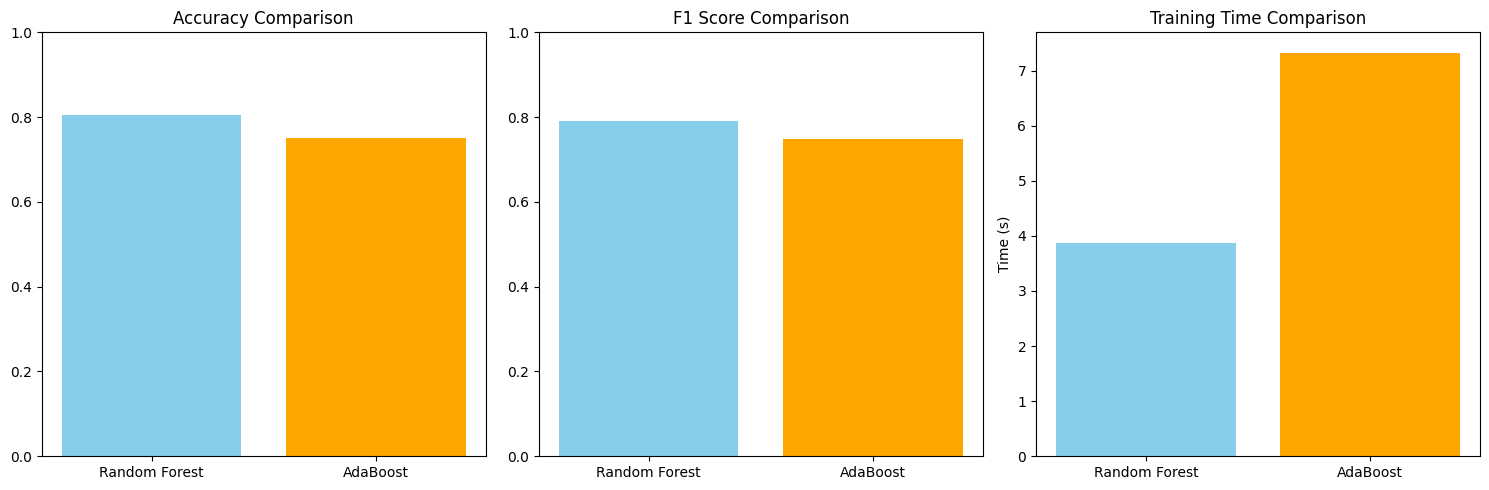

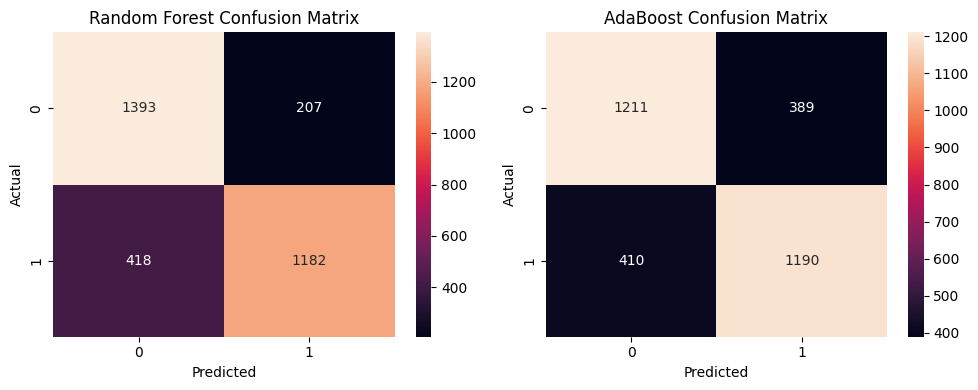


==================== Summary of Results =====================

           Model  Accuracy  F1 Score  Training Time (s)
0  Random Forest  0.804688  0.790900           3.869649
1       AdaBoost  0.750313  0.748663           7.328151


In [54]:
# ========================== IMPORT LIBRARIES ==========================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import time

# ========================== LOAD DATA ==========================
data = pd.read_csv("/content/heart_disease.csv")
print("Dataset Loaded Successfully")
print(data.head())

# ========================== DATA INFO ==========================
print("\nDataset Information:")
data.info()

# ========================== DATA PREPROCESSING ==========================
data["Heart Disease Status"] = data["Heart Disease Status"].map({"Yes":1, "No":0})

data = pd.get_dummies(data, drop_first=True)
print("\nData after encoding categorical variables:")
print(data.head())

print("\nMissing values:\n", data.isnull().sum())
data = data.fillna(data.mean())
print("\nMissing values after fixing:\n", data.isnull().sum())

X = data.drop("Heart Disease Status", axis=1)
y = data["Heart Disease Status"]
print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

# ========================== HANDLE IMBALANCED DATA ==========================
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)
print("\nAfter balancing the dataset:")
print(y.value_counts())

# ========================== SPLIT DATA ==========================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# ========================== FEATURE SCALING ==========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("\n Feature scaling applied")

# ========================== MODEL TRAINING ==========================
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced_subsample',
    random_state=42
)

# AdaBoost
ab = AdaBoostClassifier(
    n_estimators=300,
    learning_rate=0.5,
    random_state=42
)

rf.fit(X_train, y_train)
ab.fit(X_train, y_train)
print("\n Models trained successfully")

# ========================== PREDICTIONS ==========================
rf_pred = rf.predict(X_test)
ab_pred = ab.predict(X_test)

# ========================== EVALUATION METRICS ==========================
rf_acc = accuracy_score(y_test, rf_pred)
ab_acc = accuracy_score(y_test, ab_pred)
rf_f1 = f1_score(y_test, rf_pred)
ab_f1 = f1_score(y_test, ab_pred)

print("\nRandom Forest Accuracy:", rf_acc)
print("AdaBoost Accuracy:", ab_acc)

print("\nRandom Forest Classification Report:\n", classification_report(y_test, rf_pred, zero_division=1))
print("AdaBoost Classification Report:\n", classification_report(y_test, ab_pred, zero_division=1))

# ========================== COMPARISON TABLE ==========================
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Random Forest": [
        rf_acc,
        classification_report(y_test, rf_pred, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test, rf_pred, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test, rf_pred, output_dict=True)['weighted avg']['f1-score']
    ],
    "AdaBoost": [
        ab_acc,
        classification_report(y_test, ab_pred, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test, ab_pred, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test, ab_pred, output_dict=True)['weighted avg']['f1-score']
    ]
})
print("\n===== MODEL COMPARISON =====")
print(comparison)

# ========================== TRAINING TIME ==========================
start = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - start

start = time.time()
ab.fit(X_train, y_train)
ab_time = time.time() - start

print(f"\nRandom Forest training time: {rf_time:.4f} seconds")
print(f"AdaBoost training time: {ab_time:.4f} seconds")

# ========================== VISUALIZATION ==========================
models = ["Random Forest", "AdaBoost"]
accuracy = [rf_acc, ab_acc]
f1_scores = [rf_f1, ab_f1]
training_time = [rf_time, ab_time]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.bar(models, accuracy, color=['skyblue', 'orange'])
plt.title("Accuracy Comparison")
plt.ylim(0,1)

plt.subplot(1,3,2)
plt.bar(models, f1_scores, color=['skyblue', 'orange'])
plt.title("F1 Score Comparison")
plt.ylim(0,1)

plt.subplot(1,3,3)
plt.bar(models, training_time, color=['skyblue', 'orange'])
plt.title("Training Time Comparison")
plt.ylabel("Time (s)")

plt.tight_layout()
plt.show()

# ========================== CONFUSION MATRICES ==========================
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d',)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1,2,2)
cm_ab = confusion_matrix(y_test, ab_pred)
sns.heatmap(cm_ab, annot=True, fmt='d',)
plt.title("AdaBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# ========================== SUMMARY OF RESULTS ==========================
summary = pd.DataFrame({
    "Model": ["Random Forest", "AdaBoost"],
    "Accuracy": [rf_acc, ab_acc],
    "F1 Score": [rf_f1, ab_f1],
    "Training Time (s)": [rf_time, ab_time]
})
print("\n==================== Summary of Results =====================\n")
print(summary)

In [57]:
!ls /content

heart_disease.csv						    sample_data
Performance-Analysis-of-Random-Forest-and-AdaBoost---ML-mini-prjct
